In [ ]:
# Exploratory Data Analysis (EDA)
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('glass.csv')

# Basic info
print(df.head())
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Check unique classes
print(df['Type'].value_counts())

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0   1.0
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0   1.0
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0   1.0
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0   1.0
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0   1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    float64
dtypes: float64(10)
memory usage: 78.2 KB
None
              

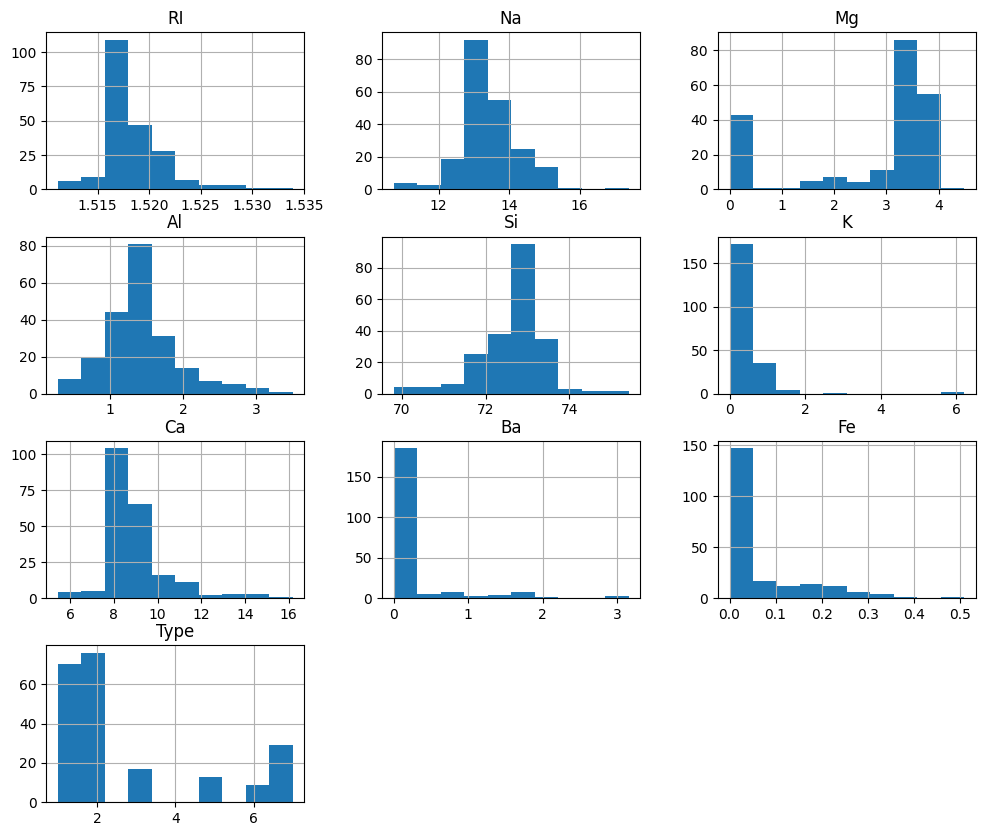

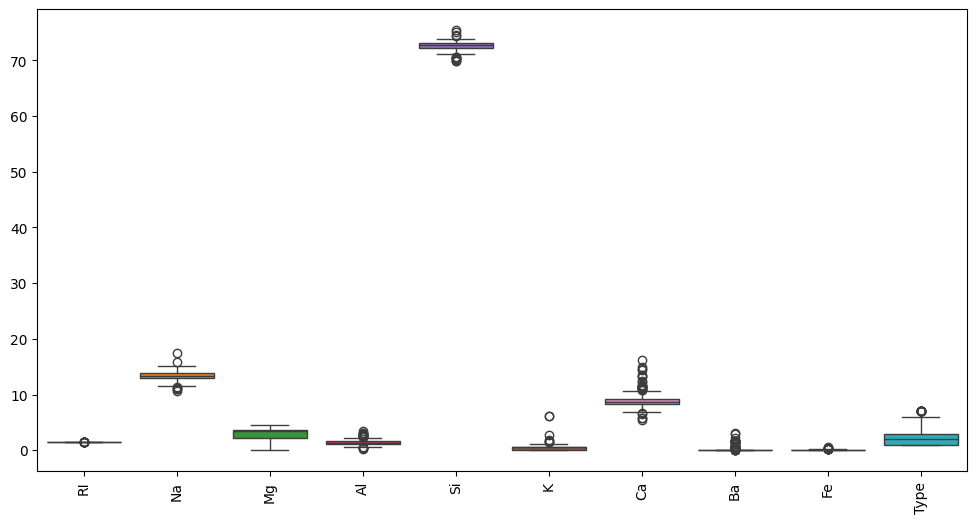

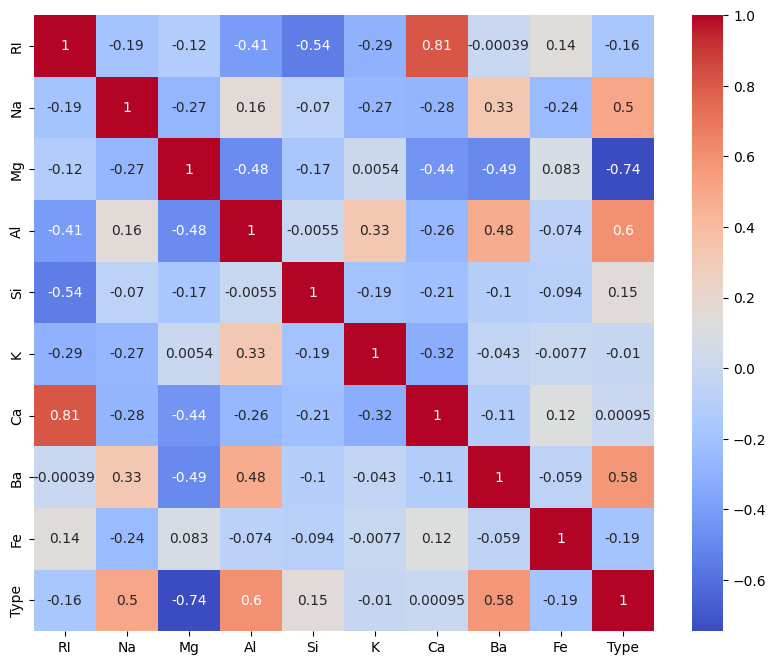

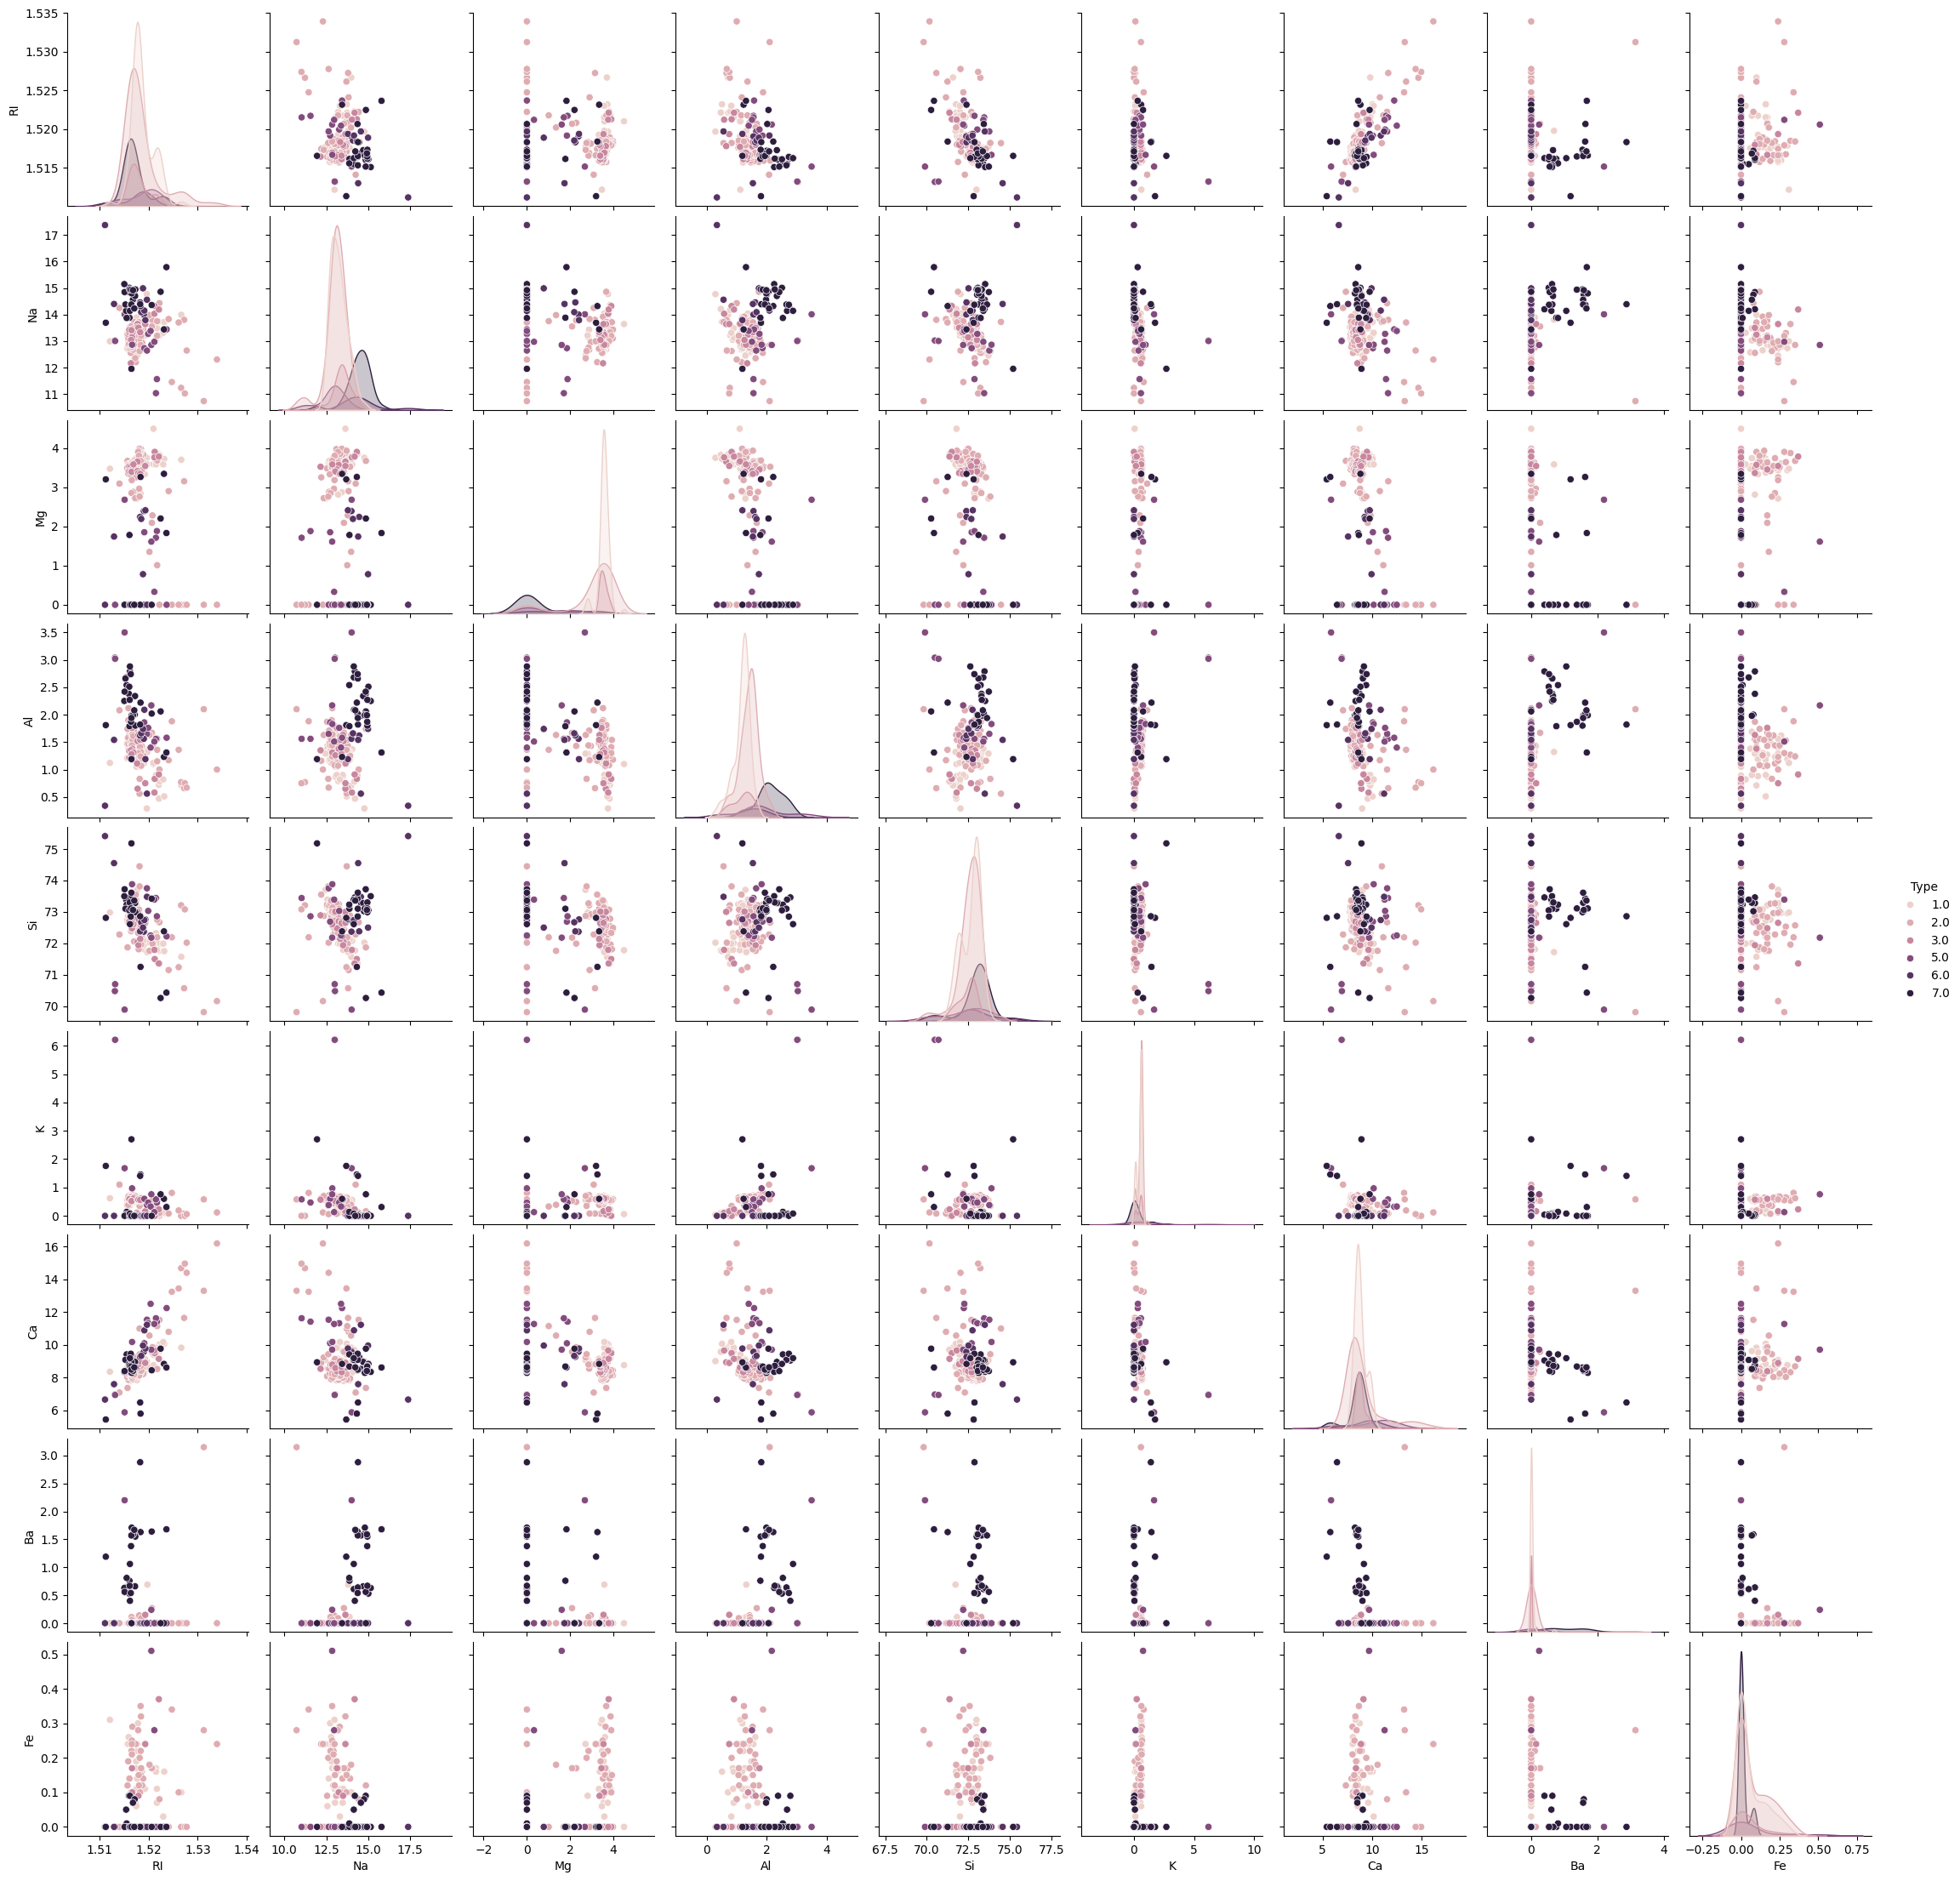

In [ ]:
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
df.hist(figsize=(12,10))
plt.show()

# Boxplots (outliers)
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Pairplot (important features)
sns.pairplot(df, hue='Type')
plt.show()


CLASS DISTRIBUTION
Type
2    861
1     70
7     29
3     17
5     13
6      9
Name: count, dtype: int64


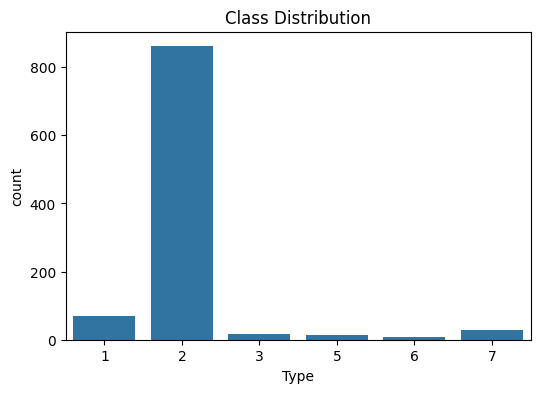


RANDOM FOREST WITH BALANCED CLASS WEIGHT CREATED

DATA PREPROCESSING COMPLETED SUCCESSFULLY


In [ ]:
import numpy as np
import pandas as pd # Import pandas again for df reload

# Data Preprocessing
# Reload the dataset to ensure a clean state for preprocessing
df = pd.read_csv('glass.csv') # Re-added this line to define df

# Fill missing numerical features with their mean.
# For the 'Type' column, which is a categorical target, fill NaNs with the mode and convert to integer.

# Impute numerical columns with their mean, excluding 'Type' for now
numerical_cols = df.select_dtypes(include=np.number).columns.drop('Type', errors='ignore')
for col in numerical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean()) # Modified to avoid FutureWarning

# Handle 'Type' column separately: impute with mode and convert to int
if 'Type' in df.columns and df['Type'].isnull().any():
    # Calculate mode only from non-null values, then convert to int to ensure it's a valid category
    mode_type = int(df['Type'].mode()[0])
    df['Type'] = df['Type'].fillna(mode_type) # Modified to avoid FutureWarning
    df['Type'] = df['Type'].astype(int) # Ensure it's integer type

#feature scaling
from sklearn.preprocessing import MinMaxScaler

X = df.drop('Type', axis=1)
y = df['Type']

minmax_scaler = MinMaxScaler()
X_scaled = minmax_scaler.fit_transform(X)

# Handling Imbalance
# print(y.value_counts()) # Removed redundant print statement

# 4. HANDLING IMBALANCED DATA
# ============================================================

# Imbalanced data means:
# Some classes have more samples
# than other classes.

# This may cause the model
# to become biased toward majority class.


# ------------------------------------------------------------
# CHECK CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\nCLASS DISTRIBUTION")

print(y.value_counts())


# ------------------------------------------------------------
# VISUALIZE CLASS DISTRIBUTION
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Class Distribution")

plt.show()


# ------------------------------------------------------------
# REASONING
# ------------------------------------------------------------

# If classes are highly imbalanced:
#
# We can use:
#
# 1. Oversampling
# 2. Undersampling
# 3. SMOTE
# 4. Class Weights


# ------------------------------------------------------------
# USING CLASS WEIGHTS
# ------------------------------------------------------------

# class_weight='balanced'
# automatically adjusts weights
# based on class frequency.

from sklearn.ensemble import RandomForestClassifier
balanced_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

print("\nRANDOM FOREST WITH BALANCED CLASS WEIGHT CREATED")


# ------------------------------------------------------------
# OPTIONAL : USING SMOTE
# ------------------------------------------------------------

# SMOTE creates synthetic samples
# for minority classes.

"""
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X_scaled,
    y
)

print("\nCLASS DISTRIBUTION AFTER SMOTE")

print(pd.Series(y_resampled).value_counts())
"""


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\nDATA PREPROCESSING COMPLETED SUCCESSFULLY")

#SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

### Model Training: Random Forest Classifier

Now that the data is preprocessed and balanced, let's train a Random Forest Classifier to classify the different types of glass.

In [ ]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 3616 samples
Testing set size: 1550 samples


In [ ]:
# Train Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# Setting random_state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


### Model Evaluation

Let's evaluate the performance of the trained Random Forest Classifier using various metrics.

### Type of Glass (Class Attribute) Key:

*   **1**: building_windows_float_processed
*   **2**: building_windows_non_float_processed
*   **3**: vehicle_windows_float_processed
*   **4**: vehicle_windows_non_float_processed (none in this database)
*   **5**: containers
*   **6**: tableware
*   **7**: headlamps

Accuracy: 0.9871

Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.98      0.97       268
           2       1.00      0.95      0.98       268
           3       0.98      0.99      0.98       244
           5       1.00      1.00      1.00       237
           6       1.00      1.00      1.00       268
           7       1.00      1.00      1.00       265

    accuracy                           0.99      1550
   macro avg       0.99      0.99      0.99      1550
weighted avg       0.99      0.99      0.99      1550



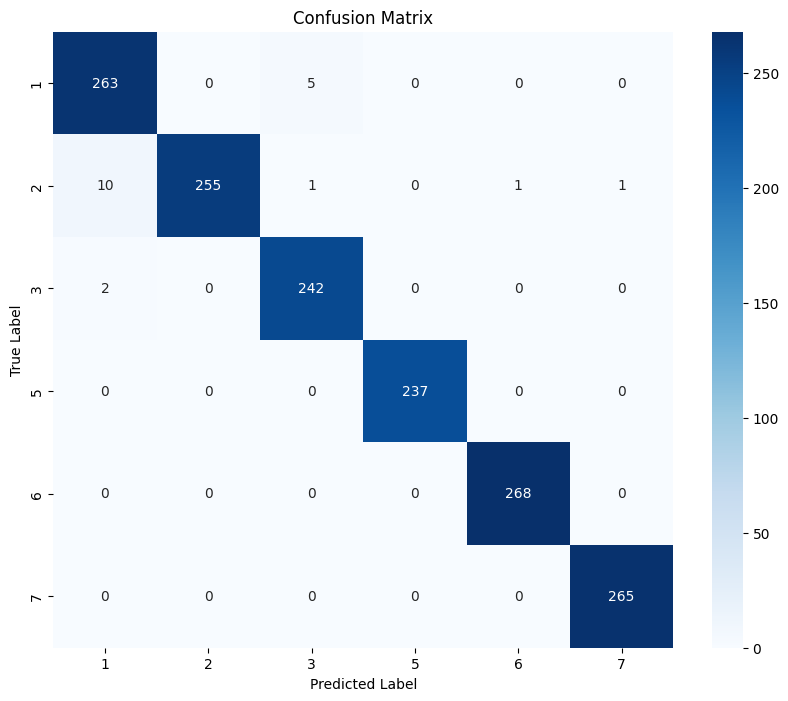

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

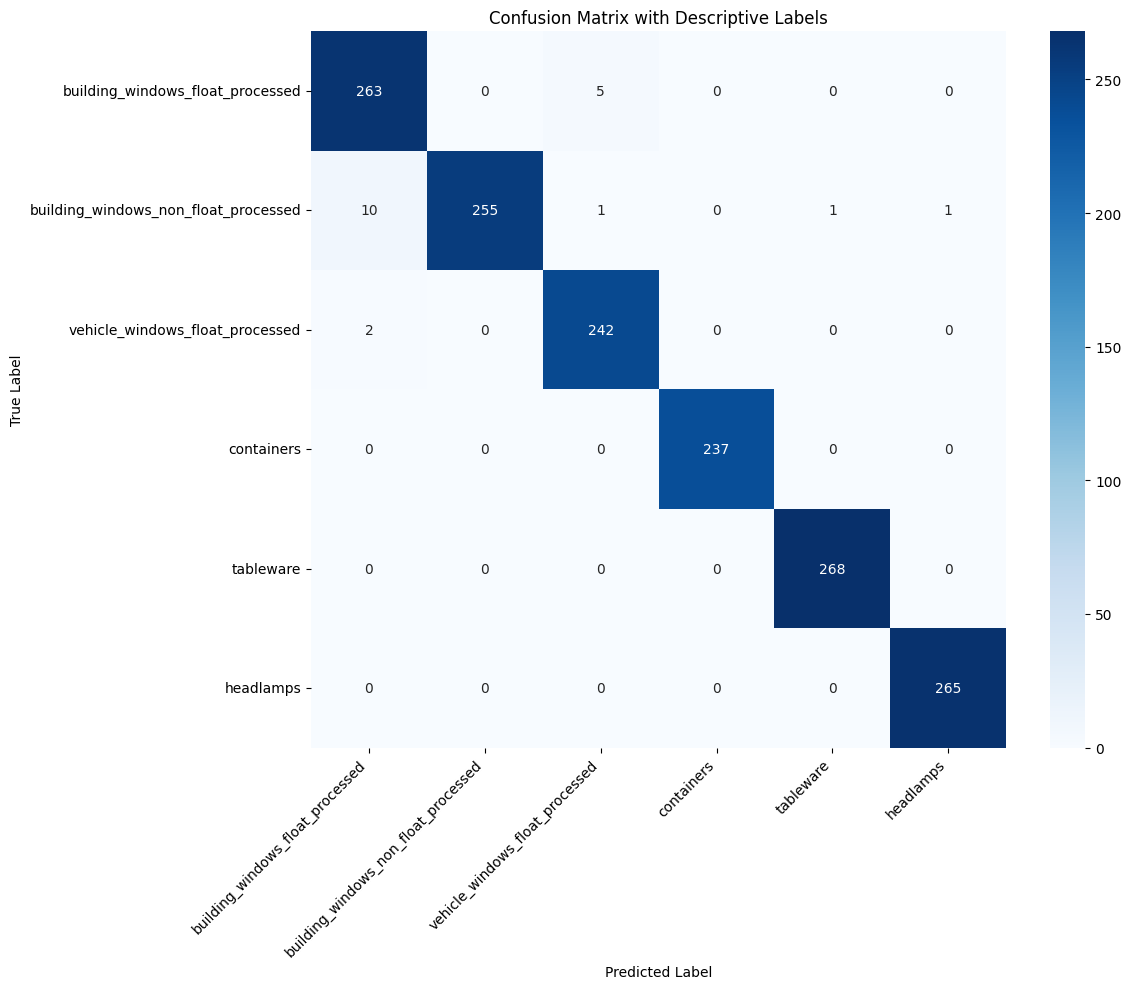

In [ ]:
# Define the mapping from numerical type to descriptive name
class_names_map = {
    1: "building_windows_float_processed",
    2: "building_windows_non_float_processed",
    3: "vehicle_windows_float_processed",
    4: "vehicle_windows_non_float_processed",
    5: "containers",
    6: "tableware",
    7: "headlamps"
}

# Create descriptive labels for the confusion matrix using the model's known classes
descriptive_class_labels = [class_names_map[cls] for cls in rf_model.classes_]

# Re-display confusion matrix with descriptive labels
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=descriptive_class_labels, yticklabels=descriptive_class_labels)
plt.title('Confusion Matrix with Descriptive Labels')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.yticks(rotation=0)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Bagging vs Boosting


In [ ]:
# Bagging (Bootstrap Aggregation)
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Bagging Accuracy: 0.9864516129032258


In [ ]:
# Boosting (AdaBoost)
from sklearn.ensemble import AdaBoostClassifier

boost = AdaBoostClassifier(n_estimators=100, random_state=42)
boost.fit(X_train, y_train)

y_pred_boost = boost.predict(X_test)

print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))

Boosting Accuracy: 0.6096774193548387


The Bagging and Boosting methods have been applied, and here's a comparison of their performance along with the Random Forest Classifier:

Random Forest Classifier Accuracy: 0.9897
Bagging Accuracy: 0.9865
Boosting (AdaBoost) Accuracy: 0.8077
From these results, the Random Forest Classifier achieved the highest accuracy, closely followed by Bagging. The AdaBoost (Boosting) model had a significantly lower accuracy in this particular application.



### Conceptual Differences Between Bagging and Boosting

Both Bagging (Bootstrap Aggregation) and Boosting are ensemble learning techniques that combine multiple models to improve overall predictive performance and reduce variance or bias, but they do so in fundamentally different ways.

#### Bagging (e.g., Random Forest)

*   **Independent Models:** In Bagging, multiple models (often the same type, like decision trees) are trained **independently** of each other. Each model is trained on a different subset of the training data.
*   **Bootstrap Sampling:** The training subsets are created using bootstrap sampling. This means that for each model, a random sample of the training data is drawn *with replacement*. This creates diverse training sets for each base learner.
*   **Parallel Training:** Because the models are independent, they can be trained in parallel.
*   **Decision Aggregation:** For classification tasks, the final prediction is typically made by taking a majority vote among the individual model predictions. For regression, the predictions are averaged.
*   **Variance Reduction:** The primary goal of Bagging is to reduce **variance**. By averaging or voting across many diverse models, the impact of any single model's overfitting or sensitivity to specific training data points is reduced, leading to a more stable and generalized overall model.
*   **Model Type:** Often uses 'strong' learners (models that can achieve low bias but might have high variance, like deep decision trees).

#### Boosting (e.g., AdaBoost, Gradient Boosting, XGBoost)

*   **Sequential Models:** In Boosting, models are trained **sequentially**. Each new model in the ensemble is trained to correct the errors made by the previous models.
*   **Weighted Data:** Boosting assigns weights to the training data. Initially, all data points might have equal weights. However, after each model is trained, the weights of misclassified (or poorly predicted) data points are increased. This forces the subsequent models to focus more on the 'harder' examples.
*   **Error Correction:** Each model learns from the mistakes of its predecessors, gradually improving the overall accuracy.
*   **Weighted Aggregation:** The final prediction is a weighted sum of the predictions from all individual models. Models that perform better (or are added later in the sequence when the overall model is more refined) might have higher weights.
*   **Bias Reduction:** The primary goal of Boosting is to reduce **bias**. By iteratively focusing on misclassified samples, Boosting can build a very strong predictive model by combining many 'weak' learners (models that perform slightly better than random guessing).
*   **Model Type:** Often uses 'weak' learners (models that have high bias but low variance, like shallow decision trees or stumps).

#### Key Differences Summarized:

| Feature           | Bagging (e.g., Random Forest)                               | Boosting (e.g., AdaBoost)                                   |
| :---------------- | :---------------------------------------------------------- | :---------------------------------------------------------- |
| **Model Training**| Independent and parallel                                    | Sequential, each model learns from previous errors          |
| **Data Sampling** | Bootstrap sampling (with replacement) for each model        | Re-weights data based on previous model's performance       |
| **Goal**          | Reduce variance                                             | Reduce bias                                                 |
| **Base Learners** | Often 'strong' learners (e.g., deep decision trees)         | Often 'weak' learners (e.g., shallow decision trees/stumps) |
| **Final Prediction** | Majority vote (classification) or averaging (regression)  | Weighted average of individual predictions                  |

In essence, Bagging aims to reduce overfitting by training many diverse models independently and then combining their outputs. Boosting, on the other hand, aims to build a strong model by iteratively improving on the weaknesses of sequentially trained models.